# AERPAW Use Case Demonstration
* This Demonstration showcases the AERPAWEnvironment's specialized funcitonality for use with the AERPAW digial twin
* Includes initialization, visualization, and SNR calculation

## This Environment Provides
* A quick and minimial initialization of the simulation environment
* Straighforward ray-tracing computation of SNR values between all transmitters and receivers in the environment
* All the existing functionality of the general environment

## What's Next
* Incorporating Blender scripting to automatically fetch topology, building, and natural environment data from OpenStreetMaps and OpenTopography for a provided region
* Integrating this functionality directly into the AERPAW environment, to provide an accurate ray-tracing SNR model

2025-09-21 15:55:09.158306: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-21 15:55:09.169039: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758484509.181413   40807 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758484509.185089   40807 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758484509.194517   40807 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

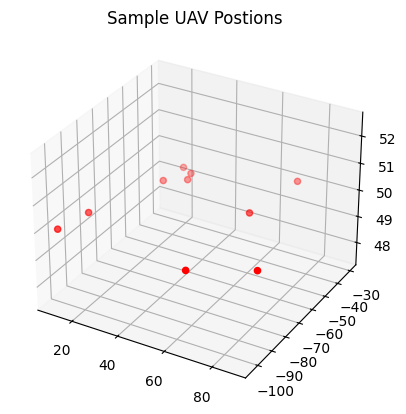

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from AERPAWEnvironment import AERPAWEnv

# Defining the scene, including receivers and transmitters

# Defining a generic UAV for simplicity
generic_uav = {
    "device_type": "tx",
    "mass": 5,
    "efficiency": 0.7,
    "position": np.zeros(3),
    "velocity": np.zeros(3),
    "color": np.array([1, 0, 0]),
    "bandwidth": 50,
    "rotor_area": 0.25,
    "signal_power": 3,
    "throughput_capacity": 625000000,
    "battery_capacity": 10000
}

# Configuring some generic uavs with random x and y positions
num_uavs = 10
uavs = []
for i in range(num_uavs):
    uav = dict(generic_uav)
    uav["position"] = np.array([np.random.rand() * 100, np.random.rand() * 100 - 110, 50])
    uavs.append(uav)

# Plotting the positions in 3d
fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],
              [uavs[i]["position"][1] for i in range(num_uavs)],
              [uavs[i]["position"][2] for i in range(num_uavs)],
              color="red")
plt.title("Sample UAV Postions")
plt.show()

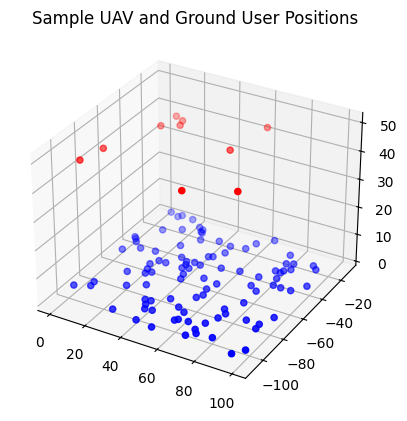

In [2]:
# Defining Generic Ground User

generic_gu = {
    "device_type": "rx",
    "position": np.zeros(3),
    "velocity": np.zeros(3),
    "color": np.array([0, 1, 0]),
    "bandwidth": 50,
    "desired_throughput": 375000
}

# Configuring some sample Ground Users
num_gus = 100
gus = []
for i in range(num_gus):
    gu = dict(generic_gu)
    gu["position"] = np.array([np.random.rand() * 100, np.random.rand() * 100 - 110, 2])
    gus.append(gu)

# Plotting UAV and Ground User Positions
fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],
              [uavs[i]["position"][1] for i in range(num_uavs)],
              [uavs[i]["position"][2] for i in range(num_uavs)],
              color="red")
axis.scatter([gus[i]["position"][0] for i in range(num_gus)],
           [gus[i]["position"][1] for i in range(num_gus)],
           [gus[i]["position"][2] for i in range(num_gus)],
           color="blue")
plt.title("Sample UAV and Ground User Positions")
plt.show()

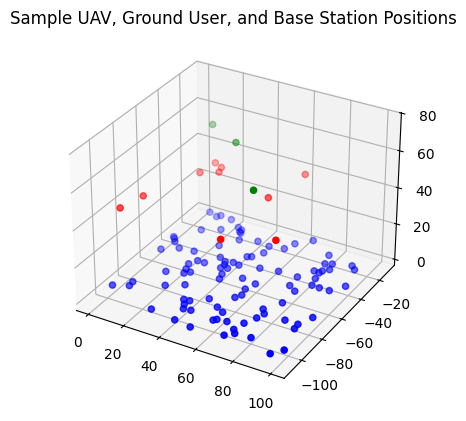

In [3]:
# Generating Sample Base Stations

# Defining a generic base station, then randomizing positions
generic_base_station = {
    "device_type": "rx",
    "position": np.zeros(3),
    "color": np.array([0, 0, 1]),
    "bandwidth": 50,
    "signal_power": 10,
    "throughput_capacity": 625000000,
    "battery_capacity": 1000000
}

# Adding some base stations with random positions
num_bs = 3
bss = []
for i in range(num_bs):
    bs = dict(generic_base_station)
    bs["position"] = np.array([np.random.rand() * 100, np.random.rand() * 100 - 110, 75])
    bss.append(bs)

# Plotting UAV, Ground User, and Base Station Positions
fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],
              [uavs[i]["position"][1] for i in range(num_uavs)],
              [uavs[i]["position"][2] for i in range(num_uavs)],
              color="red")
axis.scatter([gus[i]["position"][0] for i in range(num_gus)],
           [gus[i]["position"][1] for i in range(num_gus)],
           [gus[i]["position"][2] for i in range(num_gus)],
           color="blue")
axis.scatter([bss[i]["position"][0] for i in range(num_bs)],
           [bss[i]["position"][1] for i in range(num_bs)],
           [bss[i]["position"][2] for i in range(num_bs)],
           color="green")
plt.title("Sample UAV, Ground User, and Base Station Positions")
plt.show()

In [4]:
# Creating the scene with the sample devices
env = AERPAWEnv(scene_path='../data/RaleighUnionSquareStandardReference/raleigh_union_square.xml',
                uavs=uavs, ground_users=gus, base_stations=bss, temperature=300)
env.visualize()

In [5]:
# Computing SNR values between the transmitters and receivers in the scene
print(len(env.getSignalPowers()))

10


In [6]:
snr_dict = env.getSNR(max_depth=2, num_samples=100000, sampling_frequency=1.0, )  # Using default arguments, should be alright
print(f"Number of Recievers: {len(snr_dict)}")
print(f"Number of Transmitters: {len(snr_dict["gu0"])}")

Number of Recievers: 103
Number of Transmitters: 10


/home/everetttucker471/Documents/RL-AERPAW-DT/src/EnvironmentFramework.py:561: RuntimeWarning: divide by zero encountered in log10
  return 10 * np.log10(signal_power / noise_power)


In [7]:
print(snr_dict["gu0"])

{'uav0': 99.48103133964656, 'uav1': 95.4581451254594, 'uav2': 98.12540019598143, 'uav3': 109.5076126039755, 'uav4': 91.94311374911608, 'uav5': 97.97847039311677, 'uav6': 107.67099643674828, 'uav7': 118.91793606790546, 'uav8': 113.67702190418166, 'uav9': 96.1088916602617}


## Visualization versus AERPAW SNR Data
* To visualize the effectiveness of this model, we visualize its comparison to AERPAW SNR data generated using a path channel model
* This data is taken from the AERPAW team in the context of the AADM Challenge

In [8]:
# Reading data
import pandas as pd
import sys
sys.path.append("..")

def parseTimeToken(token):
    token = token.strip("]")
    comp = token.split(":")
    return int(comp[0]) * 3600 + int(comp[1]) * 60 + int(float(comp[2]))
    
num_aerpaw_bs = 4
snrs = []
for i in range(num_aerpaw_bs):
    snrs.append({})

with open("../data/aerpaw/vehicle_log.txt", "r") as f:
    for line in f.readlines():
        tokens = line.split(" ")
        for i in range(num_aerpaw_bs):
            if f"BS{i + 1}>SNR" in line:
                snrs[i][parseTimeToken(tokens[1])] = float(tokens[-1])

# Converting to pandas Dataframe
df = pd.DataFrame()
df.insert(0, "Time", list(snrs[0].keys()))
for i in range(num_aerpaw_bs):
    df.insert(i + 1, f"LW{i + 1}", list(snrs[i].values()))
print(df)

      Time        LW1        LW2        LW3        LW4
0    57955 -99.000000 -99.000000 -99.000000 -99.000000
1    57956 -99.000000 -99.000000 -99.000000 -99.000000
2    57957 -99.000000 -99.000000 -99.000000 -99.000000
3    57958 -99.000000 -99.000000 -99.000000 -99.000000
4    57959 -99.000000 -99.000000 -99.000000 -99.000000
..     ...        ...        ...        ...        ...
431  58386  19.168816   0.559805   1.089783  -1.818649
432  58387  19.375866   0.717394  -1.420067  -1.019251
433  58388  21.348263  -1.104740  -0.894634  -1.320980
434  58389  19.693741   0.884892  -0.262821  -2.431139
435  58390  19.506615   0.483650   0.465687  -3.688786

[436 rows x 5 columns]


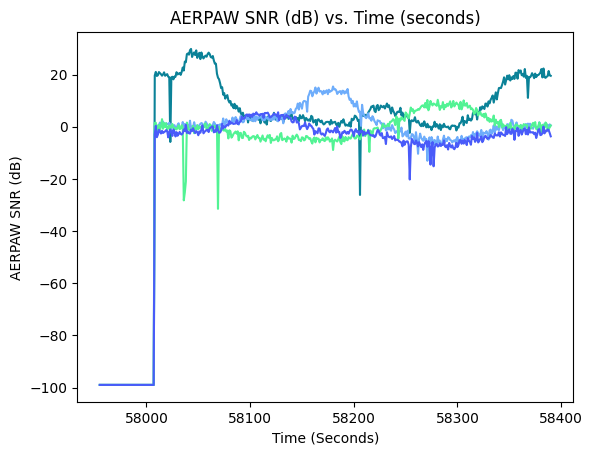

In [9]:
# Plotting the SNR values over time for visualization
for i in range(num_aerpaw_bs):
    plt.plot(df["Time"], df[f"LW{i + 1}"], color=np.random.rand(3))
plt.title("AERPAW SNR (dB) vs. Time (seconds)")
plt.xlabel("Time (Seconds)")
plt.ylabel("AERPAW SNR (dB)")
plt.show()

### AERPAW Data Inspection
* As you can see from the graph, there is a range before the simulation starts where the SNR is zeroed at -99.0
* Additionally, there are some outlier points where the SNR has a sudden drop
* Other than that, the SNR is fairly consistent over time

In [10]:
# Grabbing UAV position over time

lat = {}
lon = {}
height = {}
with open("../data/aerpaw/vehicle_out.txt", "r") as f:
    for line in f.readlines():
        tokens = line.split(",")
        time = parseTimeToken(tokens[-3].split(" ")[1])
        lat[time] = float(tokens[2])
        lon[time] = float(tokens[1])
        height[time] = float(tokens[3])

# Putting the data into local coordinates, and then into the dataframe

R = 6371201  # Radius of Earth at Raleigh, in meters
BASIS = np.array([35.733395, -78.699109, 25])
def latLon(lat_lon, basis):
    """
    Converts a single point to lat/lon, with respect to the basis point
    """
    return np.array([R * np.sin((lat_lon[0] - basis[0]) * np.pi / 180), 
                    R * np.sin((lat_lon[1] - basis[1]) * np.pi / 180), 
                    lat_lon[2]])

positions = np.array([list(lat.values()), list(lon.values()), list(height.values())]).T
print(positions.shape)
for i in range(len(positions)):
    positions[i] = latLon(positions[i], BASIS)

df.insert(5, "X", positions[:, 0])
df.insert(6, "Y", positions[:, 1])
df.insert(7, "Height", positions[:, 2])
print(df)

(436, 3)
      Time        LW1        LW2        LW3        LW4           X  \
0    57955 -99.000000 -99.000000 -99.000000 -99.000000 -697.492181   
1    57956 -99.000000 -99.000000 -99.000000 -99.000000 -697.492181   
2    57957 -99.000000 -99.000000 -99.000000 -99.000000 -697.492181   
3    57958 -99.000000 -99.000000 -99.000000 -99.000000 -697.492181   
4    57959 -99.000000 -99.000000 -99.000000 -99.000000 -697.492181   
..     ...        ...        ...        ...        ...         ...   
431  58386  19.168816   0.559805   1.089783  -1.818649 -697.392102   
432  58387  19.375866   0.717394  -1.420067  -1.019251 -697.392102   
433  58388  21.348263  -1.104740  -0.894634  -1.320980 -697.392102   
434  58389  19.693741   0.884892  -0.262821  -2.431139 -697.392102   
435  58390  19.506615   0.483650   0.465687  -3.688786 -697.403222   

              Y  Height  
0    315.147484  -0.017  
1    315.147484  -0.017  
2    315.147484  -0.017  
3    315.147484  -0.017  
4    315.147484  -0.

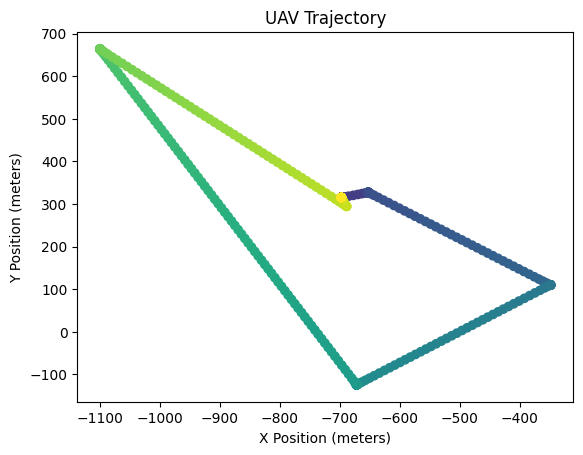

In [14]:
# Map of UAV trajectory, color-coded by time with lighter as the start

plt.scatter(df["X"], df["Y"], c=df["Time"]/max(df["Time"]))
plt.title("UAV Trajectory")
plt.xlabel("X Position (meters)")
plt.ylabel("Y Position (meters)")
plt.show()

## Generating Scene
* Now that we have the AERPAW data clearly parsed, we want to generate the same Lake Wheeler environment in the RL-DT framework
* We start by grabbing data from OpenStreetMaps, then instantiate the base stations and single UAV device
* After we have set up the simulated environment, we can move the UAV around the scene in the same pattern, and record the SNR values to each base station